In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N_STEPS_DEFAULT = 10 ** 4
EPSILON_DEFAULT = 0.05
MARGIN_DEFAULT = 1e-6

# 1. Статистический анализ результатов прямого численного моделирования

(а) Определим процедуры обновления состояния `step_stochastic_em`, `step_stochastic_rk4`, задающие временной шаг стохастической системы, и запишем стохастические системы FHN и SN. В работе будем использовать стохастический метод Рунге-Кутты 4-го порядка для обновления состояния (процедура `step_stochastic_rk4`).

In [4]:
from stochastique.core.step import step_stochastic_em, step_stochastic_rk4

FHN с аддитивным шумом в 1-м уравнении:  
$$
\begin{cases}
    \dot{x} = \frac{1}{\delta} (x - \frac{x^3}{3} - y) + \varepsilon \cdot \xi_1 \\
    \dot{y} = x + a
\end{cases}
$$

In [6]:
from stochastique.models.FHN import model_FHN, equilibria_FHN

SN с аддитивным шумом в обоих уравнениях:  
$$
\begin{cases}
    \dot{x} = y - x + \varepsilon \cdot \xi_1 \\
    \dot{y} = -a x + b y - x^2 y + \varepsilon \cdot \xi_2
\end{cases}
$$

In [8]:
from stochastique.models.SN import model_SN, equilibria_SN

(б) Для устойчивых равновесий построим облака случайных траекторий для разных значений интенсивности шума $\varepsilon$.

In [10]:
from stochastique.analysis.simulation import simulate_trajectory, simulate_stochastic_cloud

Облака траекторий системы FHN вблизи устойчивого равновесия $(\overline{x}, \overline{y}) = (-a, \frac{a^3}{3} - a)$ при $a > 1$:

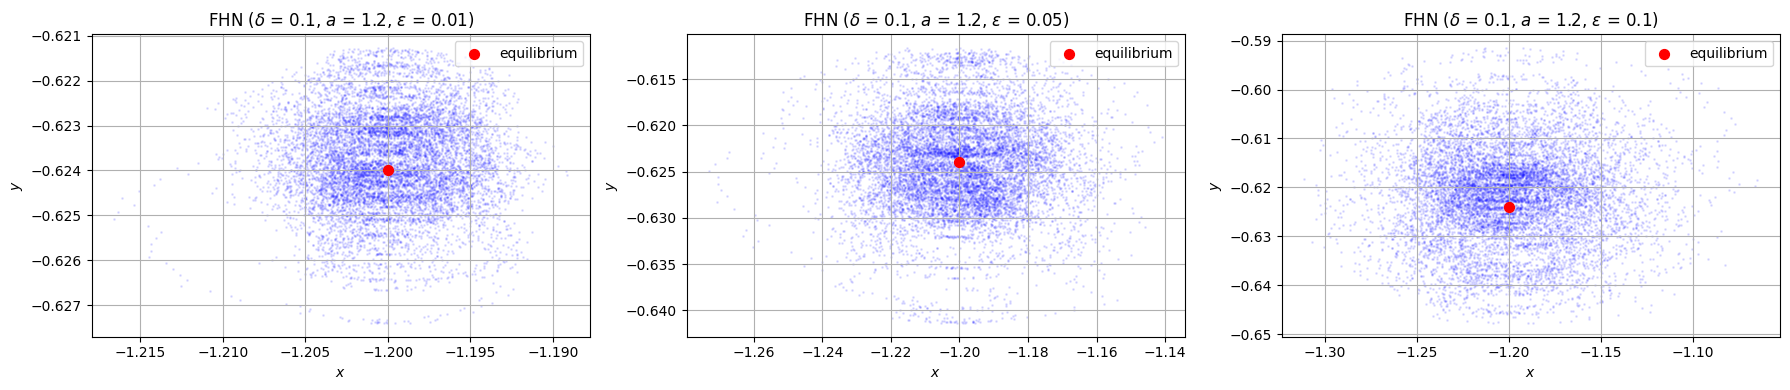

In [11]:
delta, a = 0.1, 1.2
params = dict(delta=delta, a=a)
equilibrium = equilibria_FHN(**params)[0]   # np.array([-a, a**3 / 3 - a])

noise_mask = np.array([1, 0])   # add noise to 1st equation only
epsilon_values = [0.01, 0.05, 0.1]
time_span = np.linspace(0, 100, 10 ** 4)

fig, axes = plt.subplots(1, len(epsilon_values), figsize=(18, 4))

for ax, epsilon in zip(axes, epsilon_values):
    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_FHN,
        params=params,
        state_init=equilibrium,
        time_span=time_span,
        epsilon=epsilon,
        noise_mask=noise_mask,
        num_simulations=1,
    )

    ax.set_title(rf'FHN ($\delta$ = {delta}, $a$ = {a}, $\varepsilon$ = {epsilon})')

plt.tight_layout()

Облака траекторий системы SN вблизи устойчивого равновесия $(\overline{x}, \overline{y}) = (\sqrt{b - a}, \sqrt{b - a})$ при $a < 1$.

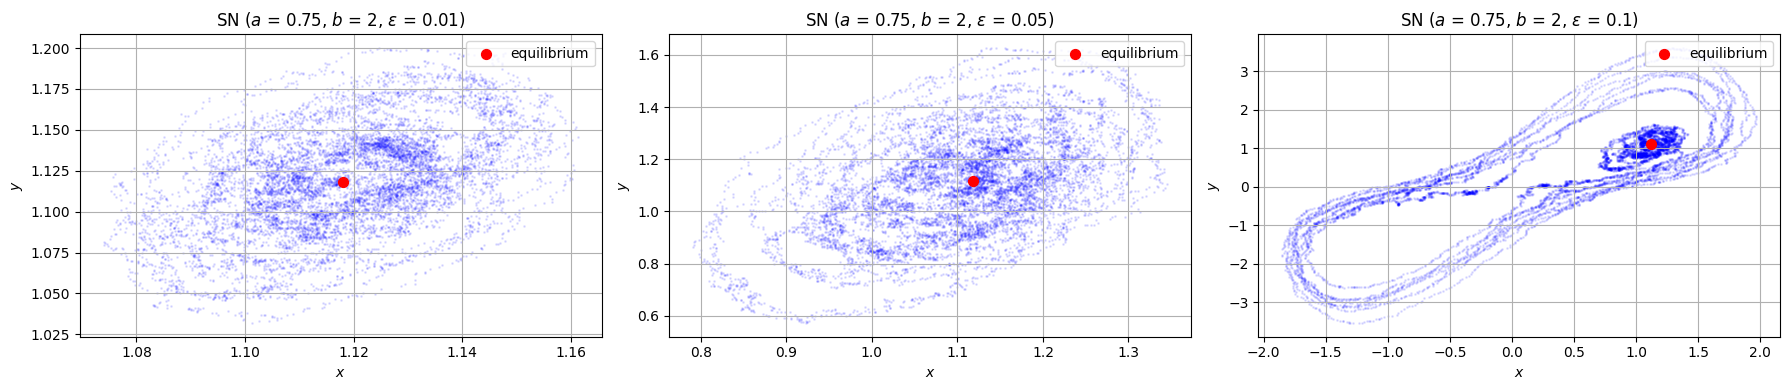

In [12]:
a, b = 0.75, 2
params = dict(a=a, b=b)
equilibrium = equilibria_SN(**params)[0]    # np.array([np.sqrt(b - a), np.sqrt(b - a)])

noise_mask = np.array([1, 1])   # add noise to both equations
epsilon_values = [0.01, 0.05, 0.1]
time_span = np.linspace(0, 100, 10 ** 4)

fig, axes = plt.subplots(1, len(epsilon_values), figsize=(18, 4))

for ax, epsilon in zip(axes, epsilon_values):
    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_SN,
        params=params,
        state_init=equilibrium,
        time_span=time_span,
        epsilon=epsilon,
        noise_mask=noise_mask,
        num_simulations=1,
    )

    ax.set_title(rf'SN ($a$ = {a}, $b$ = {b}, $\varepsilon$ = {epsilon})')

plt.tight_layout()

(в) Запишем матрицу ковариации для облака при фиксированном $\varepsilon$, найдем ее собственные числа $\overline{\lambda_1}(a), \overline{\lambda_2}(a)$.

$$
\operatorname{cov}(x, y) =
\begin{pmatrix}
    \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2 & \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) \\
    \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) & \frac{1}{n} \sum_{i=1}^n (y_i - \bar{y})^2
\end{pmatrix}
$$

In [14]:
from stochastique.core.numerical import compute_covariance_matrix_2d

Построим графики зависимостей $\overline{\lambda_1}(a), \overline{\lambda_2}(a)$ в зоне устойчивых равновесий $(a_1, a_2)$. Будем использовать значение $\varepsilon = 0.1$.

Будем использовать от $1$ до $100$ симуляций и $10^3$ шагов по времени в каждой из них, таким образом получим графики для выборок размеров $N = 1 \cdot 10^3$ и $N = 100 \cdot 10^3$.

In [16]:
from stochastique.util.plot import plot_eigenvalues_per_param_value

В модели FHN при значении параметра $a > 1$ равновесие $(x, y) = (0, 0)$ устойчиво.

In [17]:
def plot_eigenvalues_FHN(
    empirical: bool = False,
    theoretical: bool = False,
):
    delta, a = 0.1, None    # `a` is a variable parameter
    params = dict(delta=delta, a=a)
    equilibrium_func = lambda a: equilibria_FHN(a=a)[0]   # np.array([-a, a**3 / 3 - a])
    noise_mask = np.array([1, 0])   # add noise to 1st equation only

    param_name = 'a'
    param_values = np.linspace(1 + MARGIN_DEFAULT + 0.1, 5, num=20)

    trajectory_counts = [1, 10 ** 2]
    n_steps = 10 ** 3
    time_span = np.linspace(0, 10, num=n_steps)

    fig, axes = plt.subplots(1, len(trajectory_counts), figsize=(12, 4))

    from collections.abc import Iterable
    axes = axes if isinstance(axes, Iterable) else [axes]

    for ax, n_trajectories in zip(axes, trajectory_counts):
        if empirical:
            plot_eigenvalues_per_param_value(
                ax=ax,
                model_func=model_FHN,
                params=params,
                equilibrium_func=equilibrium_func,
                time_span=time_span,
                param_name=param_name,
                param_values=param_values,
                stable_range=(param_values[0], param_values[-1]),
                epsilon=EPSILON_DEFAULT,
                noise_mask=noise_mask,
                n_trajectories=n_trajectories,
                highlight=False,
                empirical=True,
            )

        if theoretical:
            plot_eigenvalues_per_param_value(
                ax=ax,
                model_func=model_FHN,
                params=params,
                equilibrium_func=equilibrium_func,
                time_span=time_span,
                param_name=param_name,
                param_values=param_values,
                stable_range=(param_values[0], param_values[-1]),
                epsilon=EPSILON_DEFAULT,
                noise_mask=noise_mask,
                n_trajectories=n_trajectories,
                highlight=False,
                empirical=False,
            )
        
        if empirical or theoretical:
            ax.set_title(rf'FHN ($\delta$ = {delta}, $\varepsilon$ = {EPSILON_DEFAULT}), $N$ = {n_trajectories * n_steps}')
            ax.set_yscale('log')
            ax.legend(loc='lower left')
        else:
            print('Plotting approach not selected! Choose between `empirical` or `theoretical`.')

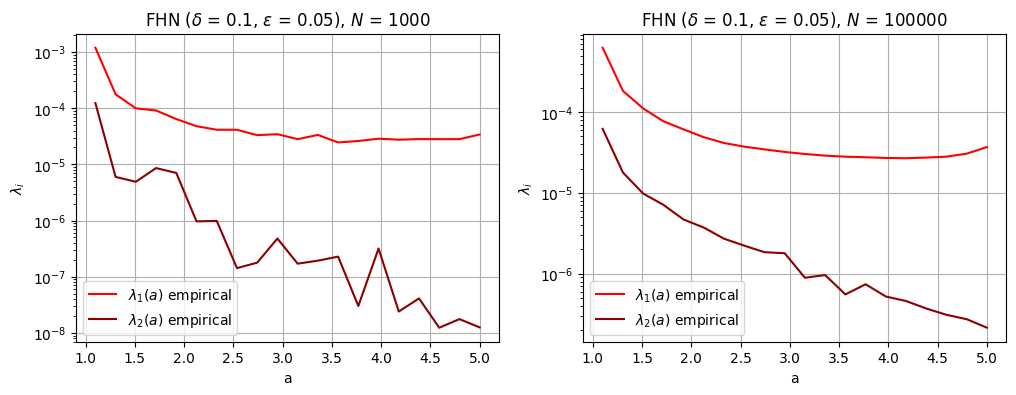

In [18]:
plot_eigenvalues_FHN(empirical=True, theoretical=False)

В модели SN при значении параметра $a < 1$ устойчивыми являются равновесия:

$$
(\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
(\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
$$

Вблизи них система ведет себя одинаково с точностью до симметрии. Рассмотрим одно из них, например $(\overline{x}_2, \overline{y}_2)$.

In [19]:
def plot_eigenvalues_SN(
    empirical: bool = False,
    theoretical: bool = False,
):
    a, b = None, 2    # `a` is a variable parameter
    params = dict(delta=delta, a=a)
    equilibrium_func = lambda a: equilibria_SN(a=a)[0]  # np.array([np.sqrt(b - a), np.sqrt(b - a)])
    noise_mask = np.array([1, 1])   # add noise to both equations

    param_name = 'a'
    param_values = np.linspace(0, 1 - MARGIN_DEFAULT, num=20)

    trajectory_counts = [1, 10 ** 2]
    n_steps = 10 ** 3
    time_span = np.linspace(0, 10, num=n_steps)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    from collections.abc import Iterable
    axes = axes if isinstance(axes, Iterable) else [axes]

    for ax, n_trajectories in zip(axes, trajectory_counts):
        if empirical:
            plot_eigenvalues_per_param_value(
                ax=ax,
                model_func=model_SN,
                params=dict(a=a, b=b),
                equilibrium_func=equilibrium_func,
                time_span=time_span,
                param_name=param_name,
                param_values=param_values,
                stable_range=(param_values[0], param_values[-1]),
                epsilon=EPSILON_DEFAULT,
                noise_mask=noise_mask,
                n_trajectories=n_trajectories,
                highlight=False,
                empirical=True,
            )
        if theoretical:
            plot_eigenvalues_per_param_value(
                ax=ax,
                model_func=model_SN,
                params=dict(a=a, b=b),
                equilibrium_func=equilibrium_func,
                time_span=time_span,
                param_name=param_name,
                param_values=param_values,
                stable_range=(param_values[0], param_values[-1]),
                epsilon=EPSILON_DEFAULT,
                noise_mask=noise_mask,
                n_trajectories=n_trajectories,
                highlight=False,
                empirical=False,
            )
    
        if empirical or theoretical:
            ax.set_title(rf'SN ($b$ = {b}, $\varepsilon$ = {EPSILON_DEFAULT}), $N$ = {n_trajectories * n_steps}')
            ax.set_yscale('log')
            ax.legend(loc='upper left')
        else:
            print('Plotting approach not selected! Choose between `empirical` or `theoretical`.')

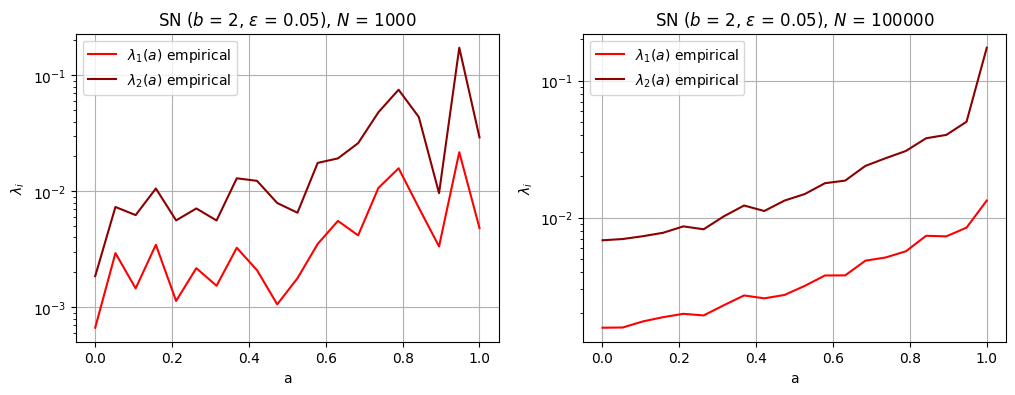

In [20]:
plot_eigenvalues_SN(empirical=True, theoretical=False)

# 2. Анализ с помощью метода стохастической чувствительности
(а) Запшем решение уравнения Ляпунова в общем виде.

$$
F W + W F^T + S S^T = 0
$$

С учетом изначальной формы СДУ:

$$
\begin{cases}
    \dot{x} = f(x, y) + \varepsilon \sigma_1(x, y) \xi_1 \\
    \dot{y} = g(x, y) + \varepsilon \sigma_2(x, y) \xi_2
\end{cases}
$$

Имеем
$$
S = 
\begin{pmatrix}
    \sigma_1(x, y) & 0 \\
    0 & \sigma_2(x, y)
\end{pmatrix}

\implies

SS^T = 
\begin{pmatrix}
    \sigma_1^2(x, y) & 0 \\
    0 & \sigma_2^2(x, y)
\end{pmatrix}
= 
\begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
$$

$$
F = 
\begin{pmatrix}
    f'_x(x, y) & f'_y(x, y) \\
    g'_x(x, y) & g'_y(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    a & b \\
    c & d
\end{pmatrix}
$$

$$
W = 
\begin{pmatrix}
    w_1 & w_2 \\
    w_2 & w_3
\end{pmatrix}
$$

Тогда уравнение (3) имеет вид:

$$
\begin{pmatrix}
    a & b \\
    c & d
\end{pmatrix}
\begin{pmatrix}
    w_1 & w_2 \\
    w_2 & w_3
\end{pmatrix}
+
\begin{pmatrix}
    w_1 & w_2 \\
    w_2 & w_3
\end{pmatrix}
\begin{pmatrix}
    a & c \\
    b & d
\end{pmatrix}
+
\begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
= 0
$$

$$
\begin{pmatrix}
    a w_1 + b w_2 & a w_2 + b w_3 \\
    c w_1 + d w_2 & c w_2 + d w_3
\end{pmatrix}
+
\begin{pmatrix}
    a w_1 + b w_2 & c w_1 + d w_2 \\
    a w_2 + b w_3 & c w_2 + d w_3
\end{pmatrix}
=
- \begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
$$

$$
\begin{pmatrix}
    2a w_1 + 2b w_2 & cw_1 + (a+d)w_2 + bw_3 \\
    cw_1 + (a+d)w_2 + bw_3 & 2c w_2 + 2d w_3
\end{pmatrix}
=
- \begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
$$

В силу симметрии матриц в левой и правой частях, получаем систему из 3-х уравнений:
$$
\begin{cases}
   2a w_1 + 2b w_2 = -s_1 \\
   c w_1 + (a+d) w_2 + b w_3 = 0 \\
   2c w_2 + 2d w_3 = -s_2
\end{cases}
\implies
\begin{cases}
    w_1 = -\frac{s_1 + 2b w_2}{2a} \\
    w_3 = -\frac{s_2 + 2c w_2}{2d} \\
    -c \cdot \frac{s_1 + 2b w_2}{2a} + (a + d) w_2 - b \cdot \frac{s_2 + 2c w_2}{2d} = 0
\end{cases}
$$

Решение относительно $w_1, w_2, w_3$:

$$
w_2 = \frac{
    \frac{c s_1}{2a} + \frac{b s_2}{2c}
}{
    a + d - \frac{b c}{a} - \frac{b c}{d}
}
$$

$$
w_1 = -\frac{s_1 + 2b w_2}{2a}
$$

$$
w_3 = -\frac{s_2 + 2c w_2}{2d}
$$

Получено явное решение, но для удобства программного решения можно представить полученную систему уравнений в матричной форме:

$$
\begin{pmatrix}
    2a & 2b & 0 \\
    c & a+d & b \\
    0 & 2c & 2d
\end{pmatrix}

\begin{pmatrix}
    w_1 \\ w_2 \\ w_3
\end{pmatrix}
=
\begin{pmatrix}
    -s_1 \\ 0 \\ -s_2
\end{pmatrix}
$$

In [22]:
from stochastique.core.numerical import find_jacobian, solve_lyapunov_symmetric_2d, stochastic_sensitivity_matrix_2d

Запишем матрицу стохастической чувствительности $W$ для FHN, где

$$
Q = SS^T = 
\begin{pmatrix}
    \sigma_1^2(x, y) & 0 \\
    0 & \sigma_2^2(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    1 & 0 \\
    0 & 0
\end{pmatrix}
$$

$$
F = 
\begin{pmatrix}
    f'_x(x, y) & f'_y(x, y) \\
    g'_x(x, y) & g'_y(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    \frac{1}{\delta} (1 - x^2) & \frac{1}{\delta} \\
    1 & 0
\end{pmatrix}
$$

In [23]:
delta, a = 0.1, 2
noise_mask = np.array([1, 0])
equilibrium_expr = np.array([-a, a**3 / 3 - a])
W = stochastic_sensitivity_matrix_2d(
    model_func=model_FHN,
    params=dict(delta=delta, a=a),
    equilibrium=equilibrium_expr,
    noise_mask=noise_mask,
)

W

array([[ 0.01666667, -0.        ],
       [-0.        ,  0.00166667]])

Запишем матрицу стохастической чувствительности $W$ для SN, где

$$
Q = SS^T = 
\begin{pmatrix}
    \sigma_1^2(x, y) & 0 \\
    0 & \sigma_2^2(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    1 & 0 \\
    0 & 1
\end{pmatrix}
$$

$$
F = 
\begin{pmatrix}
    f'_x(x, y) & f'_y(x, y) \\
    g'_x(x, y) & g'_y(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    -1 & 1 \\
    -a - 2xy & b - x^2
\end{pmatrix}
$$

In [24]:
a, b = 0.5, 2
noise_mask = np.array([1, 1])
equilibrium_expr = np.array([np.sqrt(b - a), np.sqrt(b - a)])
W = stochastic_sensitivity_matrix_2d(
    model_func=model_SN,
    params=dict(a=a, b=b),
    equilibrium=equilibrium_expr,
    noise_mask=noise_mask,
)
W

array([[1.41666667, 0.91666667],
       [0.91666667, 5.41666667]])

(б) Найдем собственные числа $\lambda_1, \lambda_2$ матрицы стохастической чувствительности $W$.

Построим зависимость $\varepsilon \cdot \lambda_1(a), \varepsilon \cdot \lambda_2(a)$ для $\varepsilon$ из пункта 1 (б) для системы FHN.

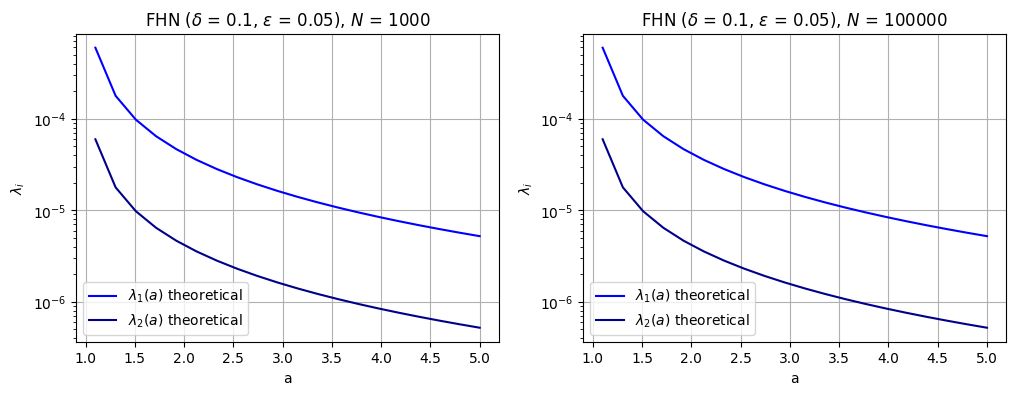

In [25]:
plot_eigenvalues_FHN(empirical=False, theoretical=True)

Построим зависимость $\varepsilon \cdot \lambda_1(a), \varepsilon \cdot \lambda_2(a)$ для $\varepsilon$ из пункта 1 (б) для системы SN.

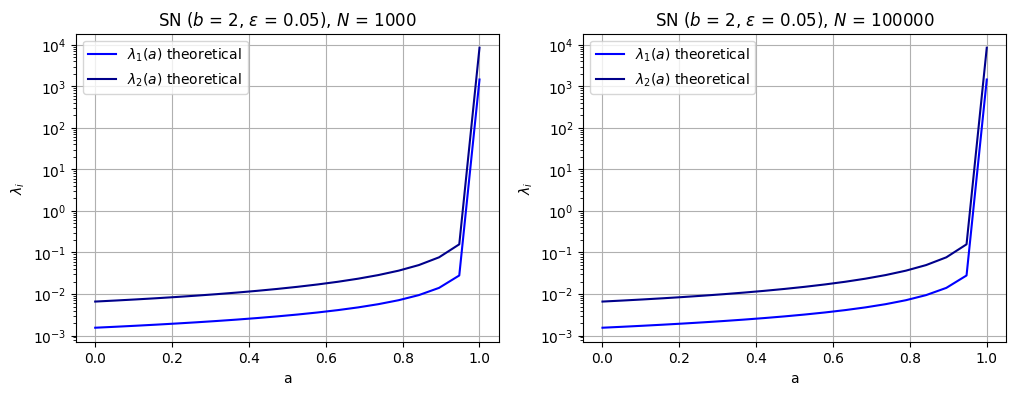

In [26]:
plot_eigenvalues_SN(empirical=False, theoretical=True)

Изобразим эмпирическую и теоретическую зависимости на одном графике и сравним их.
Эмпирический и теоретический графики схожи по крупномасштабной структуре и по характеру изменения.
Видно, что при увеличении размера выборки эмпирический график становится более гладким и приближается к теоретическому.
Однако, для обеих моделей при приближении к границе интервала стабильности равновесных точек (в правых частях графиков) разница между значениями эмпирического и теоретического графиков растет.

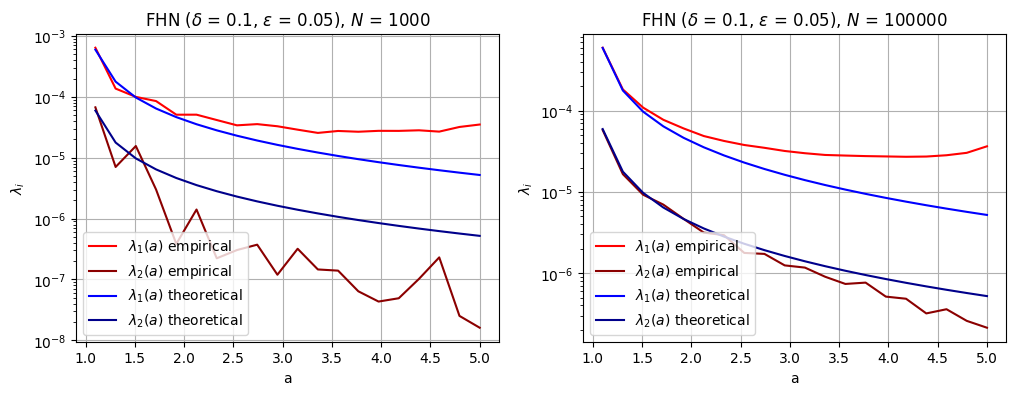

In [27]:
plot_eigenvalues_FHN(empirical=True, theoretical=True)

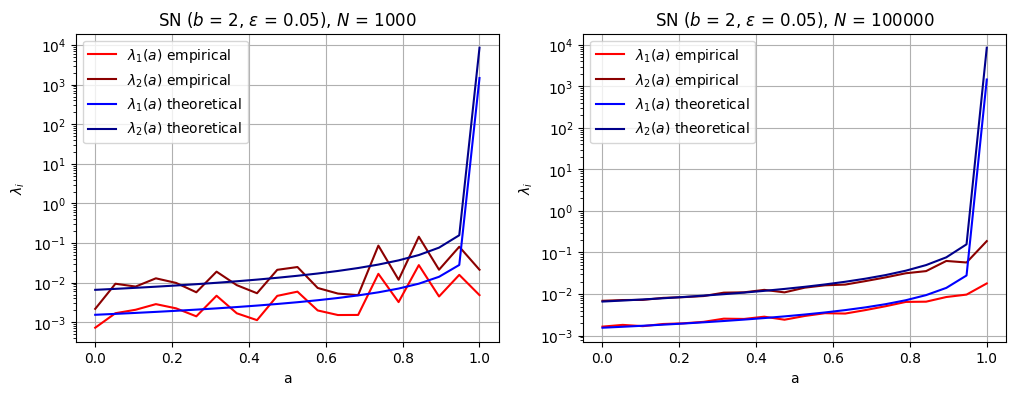

In [28]:
plot_eigenvalues_SN(empirical=True, theoretical=True)

## Доверительные эллипсы
(в) Для выбранных нескольких значений параметра $a$ построим доверительные эллипсы (возьмем облако из пункта 1 (б)).

В двумерном случае матрица стохастической чувствительности $W$ характеризует дисперсию решений стохастической системы вокруг устойчивого равновесия $\overline{x} = (\overline{x_1}, \overline{x_2})$ в форме доверительного эллипса:

$$
\frac{z_1^2}{\lambda_1} + \frac{z_2^2}{\lambda_2} = 2k^2 \varepsilon^2
$$

Пусть $\lambda_1, \lambda_2$ -- собственные числа матрицы $W$, а $V$ -- матрица собственных векторов $v_1 = (v_{11}, v_{21})^T$, $v_2 = (v_{12}, v_{22})^T$, записанных по столбцам:

$$
V = \begin{pmatrix} v_{11} & v_{12} \\ v_{21} & v_{22} \end{pmatrix}
$$

Координаты $x = (x_1, x_2)$ доверительного эллипса в базисе собственных векторов могут быть записаны так:

$$
x = \overline{x} + V \cdot \begin{pmatrix} z_1 \\ z_2 \end{pmatrix},
$$
где $z_1(\varphi) = \sqrt{2\lambda_1} \cdot \varepsilon \cdot k \cdot \cos\varphi$, $z_2(\varphi) = \sqrt{2\lambda_2} \cdot \varepsilon \cdot k \cdot \sin\varphi$ ($0 \leq \varphi \leq 2\pi$).

Коэффициент $k$ связан с доверительной вероятностью $P$ попадания решений стохастической системы в доверительный эллипс:

$$
k = \sqrt{-\ln(1 - P)}
$$

In [30]:
from stochastique.util.plot import plot_confidence_ellipse_2d

Построим доверительные эллипсы для системы FHN. Рассмотрим несколько значений параметра $a$ внутри интервала, где рассматриваемое равновесие сохраняет устойчивость.

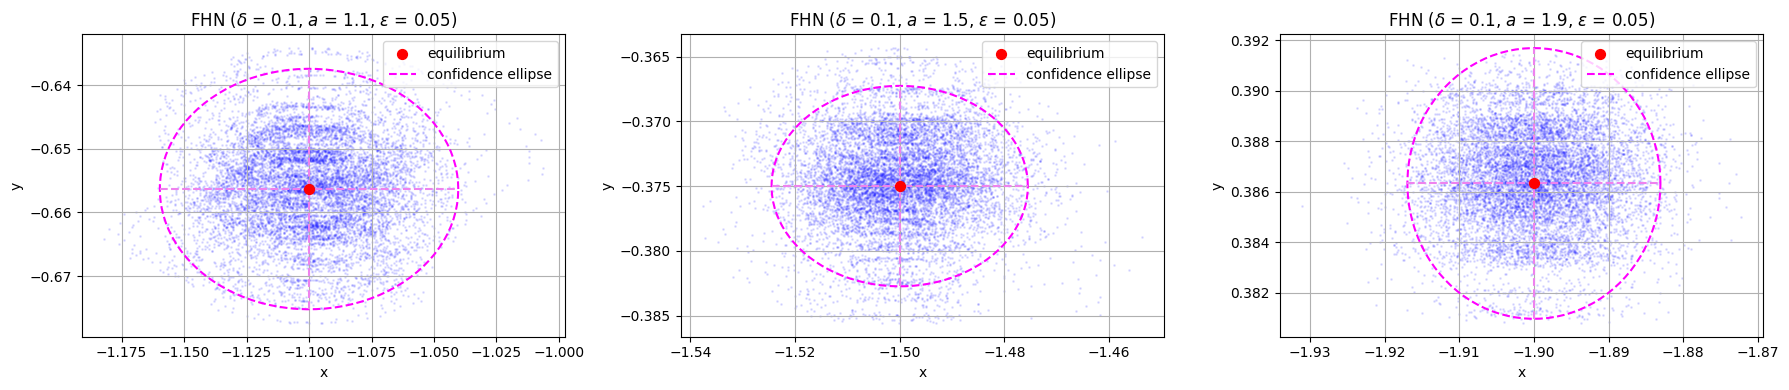

In [34]:
delta, a = 0.1, 1.2
noise_mask = np.array([1, 0])

param_name = 'a'
param_values = [1.1, 1.5, 1.9]

confidence = 0.95
time_span = np.linspace(0, 10, 10 ** 3)

fig, axes = plt.subplots(1, len(param_values), figsize=(18, 4))

for ax, val in zip(axes, param_values):
    a = val
    equilibrium_func = equilibria_FHN(a=a)[0]  # np.array([-a, a**3 / 3 - a])
    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        state_init=equilibrium_func,
        time_span=time_span,
        epsilon=EPSILON_DEFAULT,
        noise_mask=noise_mask,
        num_simulations=10,
    )

    W = stochastic_sensitivity_matrix_2d(
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium_func,
        noise_mask=noise_mask,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium_func,
        W=W,
        epsilon=EPSILON_DEFAULT,
        confidence=confidence,
        major_axes=True,
    )
    ax.set_title(rf'FHN ($\delta$ = {delta}, $a$ = {a}, $\varepsilon$ = {EPSILON_DEFAULT})')

plt.tight_layout()

Построим доверительные эллипсы для системы SN. Рассмотрим несколько значений параметра $a$ внутри интервала, где рассматриваемое равновесие сохраняет устойчивость.

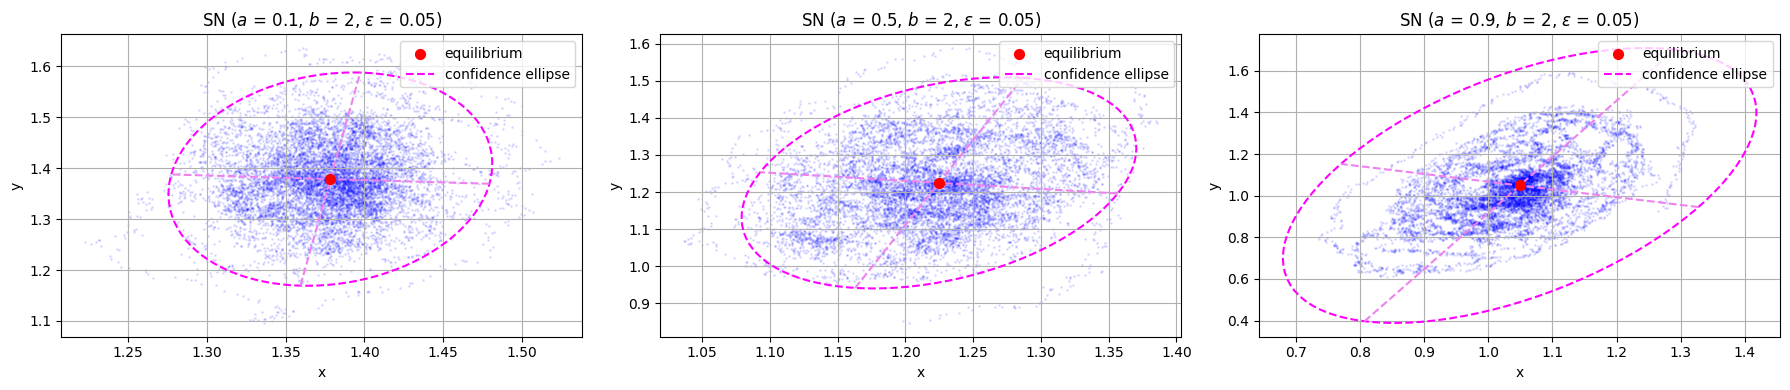

In [37]:
a, b = 0.75, 2
noise_mask = np.array([1, 1])   # add noise to both equations

param_name = 'a'
param_values = [0.1, 0.5, 0.9]

confidence = 0.95
time_span = np.linspace(0, 10, 10 ** 3)

fig, axes = plt.subplots(1, len(param_values), figsize=(18, 4))

for ax, val in zip(axes, param_values):
    a = val
    equilibrium_expr = np.array([np.sqrt(b - a), np.sqrt(b - a)])
    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_SN,
        params=dict(a=a, b=b),
        state_init=equilibrium_expr,
        time_span=time_span,
        epsilon=EPSILON_DEFAULT,
        noise_mask=noise_mask,
        num_simulations=10,
    )

    W = stochastic_sensitivity_matrix_2d(
        model_func=model_SN,
        params=dict(a=a, b=b),
        equilibrium=equilibrium_expr,
        noise_mask=noise_mask,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium_expr,
        W=W,
        epsilon=EPSILON_DEFAULT,
        confidence=confidence,
        major_axes=True,
    )
    ax.set_title(rf'SN ($a$ = {a}, $b$ = {b}, $\varepsilon$ = {EPSILON_DEFAULT})')

plt.tight_layout()